# Robot Manufacturing Data Wrangling
## Part 1 — Original Data Inspection

### Objective
Inspect the original robot electrical-current dataset before cleaning,
transforming, or combining it with synthetic manufacturing records.

### Data Sources
- **Observed data:** Original measurements from `RMBR4-2_export_test.csv`.
- **Synthetic data:** Shop information and manufacturing operations
  to be created later for this educational exercise.

### Data Integrity
The original CSV will remain unchanged. Synthetic assignments will be
identified explicitly and will not be presented as actual factory events.

### 1. Verify the Python Environment
Import the analysis libraries and confirm that this notebook uses
the project's virtual environment.

In [2]:
# Import tools for tabular data, numerical operations, and visualization.
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Check that the notebook uses this project's Python environment.
print("Python executable:", sys.executable)
print("Pandas version:", pd.__version__)
print("Environment ready.")

Python executable: c:\AI\PROG8245\WranglingWorkshop\.venv\Scripts\python.exe
Pandas version: 3.0.6
Environment ready.


### 2. Load the Original Dataset

Read the robot CSV into a pandas DataFrame called `electrical_current_raw`.

Each row contains a timestamp, a measurement type (`Trait`), and
recorded axis channels. We will inspect all original columns before
selecting the six channels used in our manufacturing simulation.

This step only reads the source file; it does not modify it.

In [3]:
from pathlib import Path
from IPython.display import display

# Locate the project whether the notebook runs from the project
# folder or from its notebooks subfolder.
current_folder = Path.cwd()
relative_source = Path("data/raw/RMBR4-2_export_test.csv")

if (current_folder / relative_source).is_file():
    project_root = current_folder
elif (current_folder.parent / relative_source).is_file():
    project_root = current_folder.parent
else:
    raise FileNotFoundError(
        "Original CSV not found. Check the data/raw folder."
    )

source_path = project_root / relative_source

# Load all original columns without changing the source CSV.
electrical_current_raw = pd.read_csv(source_path)

# Inspect the dataset size, column names, and first five records.
print("Source file:", source_path.name)
print(f"Rows: {electrical_current_raw.shape[0]:,}")
print(f"Columns: {electrical_current_raw.shape[1]}")
print("Column names:", electrical_current_raw.columns.tolist())

display(electrical_current_raw.head())

Source file: RMBR4-2_export_test.csv
Rows: 39,672
Columns: 16
Column names: ['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time']


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


### 3. Inspect Data Types and Missing Values

Before cleaning the dataset, inspect its structure and completeness.

- `info()` summarizes column types and non-null counts.
- `isna().sum()` counts missing values in each column.
- `describe()` summarizes the numerical measurements.

Zero values and missing values have different meanings. We will preserve
recorded zeros and will not replace missing measurements with zero.
Empty channels will be documented before selecting the analysis columns.

In [4]:
# Inspect the original column types and non-null counts.
electrical_current_raw.info()

# Build a column-level completeness report.
missing_summary = pd.DataFrame({
    "DataType": electrical_current_raw.dtypes.astype(str),
    "NonMissingCount": electrical_current_raw.notna().sum(),
    "MissingCount": electrical_current_raw.isna().sum(),
    "MissingPercent": (
        electrical_current_raw.isna().mean() * 100
    ).round(2),
})
missing_summary.index.name = "Column"

display(missing_summary)

# Check which measurement types are present, including missing labels.
print("Measurement types:")
display(electrical_current_raw["Trait"].value_counts(dropna=False))

# Summarize all original axis channels before selecting six of them.
axis_columns = [
    f"Axis #{axis_number}" for axis_number in range(1, 15)
]
display(electrical_current_raw[axis_columns].describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 39672 entries, 0 to 39671
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Trait     39672 non-null  str    
 1   Axis #1   39672 non-null  float64
 2   Axis #2   39672 non-null  float64
 3   Axis #3   39672 non-null  float64
 4   Axis #4   39672 non-null  float64
 5   Axis #5   39672 non-null  float64
 6   Axis #6   39672 non-null  float64
 7   Axis #7   39672 non-null  float64
 8   Axis #8   39672 non-null  float64
 9   Axis #9   0 non-null      float64
 10  Axis #10  0 non-null      float64
 11  Axis #11  0 non-null      float64
 12  Axis #12  0 non-null      float64
 13  Axis #13  0 non-null      float64
 14  Axis #14  0 non-null      float64
 15  Time      39672 non-null  str    
dtypes: float64(14), str(2)
memory usage: 4.8 MB


,DataType,NonMissingCount,MissingCount,MissingPercent
Column,,,,
Trait,str,39672,0,0.0
Axis #1,float64,39672,0,0.0
Axis #2,float64,39672,0,0.0
Axis #3,float64,39672,0,0.0
Axis #4,float64,39672,0,0.0
Axis #5,float64,39672,0,0.0
Axis #6,float64,39672,0,0.0
Axis #7,float64,39672,0,0.0
Axis #8,float64,39672,0,0.0


Measurement types:


Trait
current    39672
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Axis #1,39672.0,0.725743,2.162120,0.0,0.0,0.0,0.31271,23.60930
Axis #2,39672.0,3.613374,6.879962,0.0,0.0,0.0,4.21719,51.71323
Axis #3,39672.0,2.710336,5.111901,0.0,0.0,0.0,4.58619,41.85556
Axis #4,39672.0,0.620222,1.574897,0.0,0.0,0.0,0.51619,15.66630
Axis #5,39672.0,0.954521,2.100186,0.0,0.0,0.0,0.80009,20.75076
Axis #6,39672.0,0.599427,1.815498,0.0,0.0,0.0,0.36133,20.93142
Axis #7,39672.0,0.870145,2.166811,0.0,0.0,0.0,0.31003,8.10848
Axis #8,39672.0,0.102214,0.423075,0.0,0.0,0.0,0.07848,5.90564
Axis #9,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Axis #10,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Inspection Findings

- Axis channels 1–8 contain 39,672 non-missing values each.
- Axis channels 9–14 are entirely empty.
- The six-unit simulation will use channels 1–6.
- Channels 7–8 remain in the original dataset but are outside
  the scope of this simulation.
- `Time` is currently stored as text and requires datetime conversion.

### 4. Prepare the Analysis Copy and Validate Timestamps

Create a separate working DataFrame containing the timestamp,
measurement type, and six selected channels.

Convert timestamps to UTC and check for missing or invalid timestamps,
duplicates, and chronological order before assigning operations.
The original DataFrame and CSV remain unchanged.

In [5]:
# Select six channels for the agreed simulation scope.
selected_axes = [f"Axis #{number}" for number in range(1, 7)]

# Create an independent analysis copy and standardize the time column name.
electrical_current = electrical_current_raw[
    ["Time", "Trait"] + selected_axes
].copy()

electrical_current = electrical_current.rename(
    columns={"Time": "Timestamp"}
)

# Convert timestamp strings to timezone-aware UTC values.
# Unparseable values become NaT so they can be counted and investigated.
electrical_current["Timestamp"] = pd.to_datetime(
    electrical_current["Timestamp"],
    utc=True,
    errors="coerce",
)

timestamps = electrical_current["Timestamp"]
valid_timestamps = timestamps.dropna()

# Report time quality before sorting, deleting, or filling any records.
time_summary = pd.Series({
    "Missing or invalid timestamps": int(timestamps.isna().sum()),
    "Duplicate valid timestamps": int(valid_timestamps.duplicated().sum()),
    "Chronological order": valid_timestamps.is_monotonic_increasing,
    "First timestamp (UTC)": valid_timestamps.min(),
    "Last timestamp (UTC)": valid_timestamps.max(),
    "Observed time span": valid_timestamps.max() - valid_timestamps.min(),
}, name="Result")

display(time_summary.to_frame())

# Stop here if any timestamps require correction.
if timestamps.isna().any():
    raise ValueError("Investigate missing or invalid timestamps before continuing.")

display(electrical_current.head())

,Result
Missing or invalid timestamps,0
Duplicate valid timestamps,0
Chronological order,True
First timestamp (UTC),2022-10-17 12:18:23.660000+00:00
Last timestamp (UTC),2022-10-18 10:44:58.628000+00:00
Observed time span,0 days 22:26:34.968000


,Timestamp,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6
0,2022-10-17 12:18:23.660000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0


### 5. Inspect Sampling Intervals

Calculate the elapsed time between consecutive measurements.

The median interval describes the typical sampling cadence.
Longer intervals identify periods with reduced observation coverage;
they do not prove that production stopped.

For this exploratory review, intervals longer than 10 seconds are
flagged for inspection. This threshold is an analysis choice,
not a manufacturer specification.

No measurements will be interpolated or added.

In [6]:
# Require unique, chronologically ordered timestamps before calculating gaps.
timestamps = electrical_current["Timestamp"]

if timestamps.duplicated().any() or not timestamps.is_monotonic_increasing:
    raise ValueError(
        "Resolve duplicate or unordered timestamps before analyzing intervals."
    )

# Calculate elapsed seconds between consecutive records.
# The first record has no preceding observation, so its interval is missing.
sampling_intervals = timestamps.diff().dt.total_seconds()

print("Sampling interval summary (seconds):")
display(
    sampling_intervals.describe(
        percentiles=[0.50, 0.95, 0.99]
    ).to_frame("Seconds")
)

# Flag unusually long intervals without assigning a manufacturing cause.
gap_threshold_seconds = 10.0

sampling_gaps = pd.DataFrame({
    "PreviousTimestamp": timestamps.shift(1),
    "CurrentTimestamp": timestamps,
    "GapSeconds": sampling_intervals,
})

sampling_gaps = sampling_gaps.loc[
    sampling_gaps["GapSeconds"] > gap_threshold_seconds
].copy()

print(f"Intervals longer than {gap_threshold_seconds:g} seconds: "
      f"{len(sampling_gaps):,}")

# Show the ten largest gaps, keeping both endpoints for traceability.
display(sampling_gaps.nlargest(10, "GapSeconds"))

Sampling interval summary (seconds):


,Seconds
count,39671.000000
mean,2.036625
std,2.713063
min,1.714000
50%,1.891000
95%,2.003000
99%,6.007300
max,402.538000


Intervals longer than 10 seconds: 6


,PreviousTimestamp,CurrentTimestamp,GapSeconds
257,2022-10-17 12:27:00.597000+00:00,2022-10-17 12:33:43.135000+00:00,402.538
1106,2022-10-17 13:02:12.324000+00:00,2022-10-17 13:07:44.934000+00:00,332.610
13795,2022-10-17 20:15:10.766000+00:00,2022-10-17 20:15:44.156000+00:00,33.390
4844,2022-10-17 15:13:22.042000+00:00,2022-10-17 15:13:55.155000+00:00,33.113
5423,2022-10-17 15:33:24.605000+00:00,2022-10-17 15:33:57.655000+00:00,33.050
8104,2022-10-17 17:03:23.722000+00:00,2022-10-17 17:03:56.535000+00:00,32.813


### Sampling Findings

- The median sampling interval is 1.891 seconds.
- Six intervals exceed the exploratory 10-second threshold.
- The largest interval is 402.538 seconds.
- These gaps indicate unavailable observations between timestamps,
  not confirmed production stops.

### 6. Visualize the Original Current Patterns

Calculate five-minute averages to make the full recording easier
to inspect. Each average represents the available samples in that
window; it is not a time-weighted average.

The shaded regions mark sampling gaps longer than 10 seconds.
Aggregation hides short peaks, so this chart is for pattern exploration,
not peak-current analysis.

Current is displayed in recorded units because the physical units
have not been independently verified.

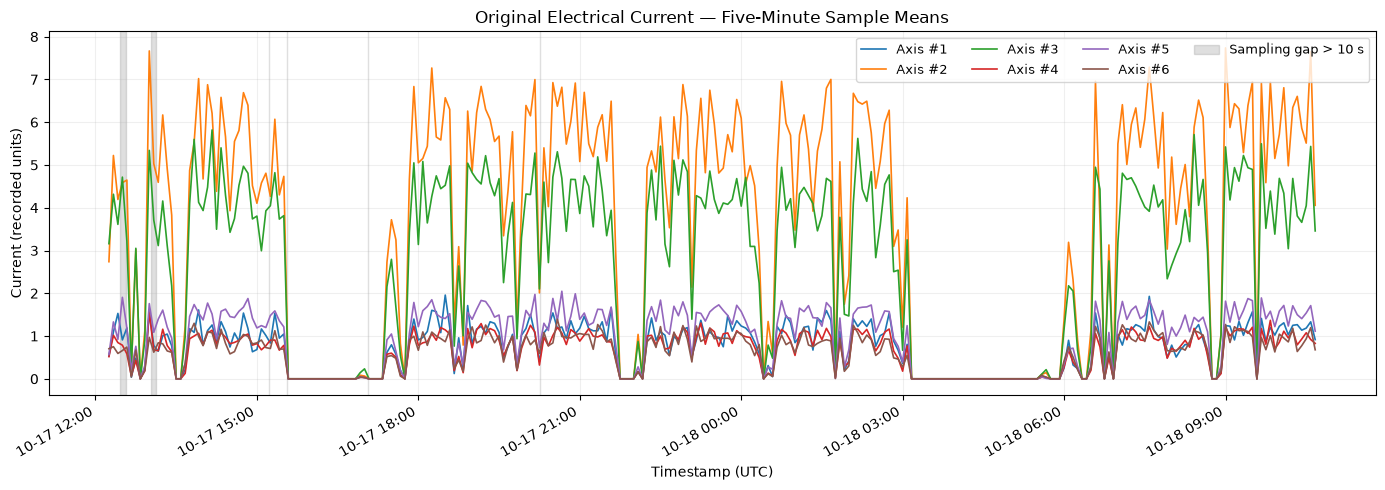

In [7]:
import matplotlib.dates as mdates

# Use timestamps as the index to group measurements into time windows.
current_by_time = electrical_current.set_index("Timestamp")[selected_axes]

# Calculate sample-based means without filling missing observations.
current_5min = current_by_time.resample("5min").mean()

fig, ax = plt.subplots(figsize=(14, 5))

# Draw one line per original channel.
for channel in selected_axes:
    ax.plot(
        current_5min.index,
        current_5min[channel],
        label=channel,
        linewidth=1.2,
    )

# Highlight gaps so unavailable observations remain visible.
for number, gap in enumerate(sampling_gaps.itertuples(index=False)):
    ax.axvspan(
        gap.PreviousTimestamp,
        gap.CurrentTimestamp,
        color="gray",
        alpha=0.25,
        label="Sampling gap > 10 s" if number == 0 else None,
    )

ax.set_title("Original Electrical Current — Five-Minute Sample Means")
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Current (recorded units)")
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d %H:%M", tz=current_by_time.index.tz)
)
ax.grid(alpha=0.2)
ax.legend(ncol=4, fontsize=9)
fig.autofmt_xdate()
fig.tight_layout()

plt.show()

### 7. Findings and Manufacturing Simulation Implications

The five-minute averages show higher recorded current in channels 2
and 3, along with several low-current periods shared across channels.

These observations describe the electrical recording. They do not
identify welding, painting, equipment faults, or confirmed downtime.

For the educational simulation:
- Channels 1–6 will represent six fictional manufacturing work units.
- Manufacturing roles, products, colors, and operation records will
  be synthetic and explicitly labeled.
- Any scheduling decisions informed by this recording will be
  documented as simulation assumptions.
- Recorded current values will remain unchanged.

### 8. Export Inspection Results

Save the six-channel working dataset, data-quality summaries, sampling
gaps, and chart in separate output folders.

The original CSV remains unchanged. Rerunning this section refreshes
only these derived outputs.

In [8]:
# Create separate locations for derived data and inspection reports.
processed_dir = project_root / "data" / "processed"
inspection_dir = project_root / "reports" / "data_inspection"

processed_dir.mkdir(parents=True, exist_ok=True)
inspection_dir.mkdir(parents=True, exist_ok=True)

# Export the six-channel analysis copy with UTC timestamps.
electrical_current.to_csv(
    processed_dir / "electrical_current_six_channels.csv",
    index=False,
)

# Preserve the inspection evidence for later review.
missing_summary.to_csv(
    inspection_dir / "column_completeness.csv"
)
time_summary.to_frame().to_csv(
    inspection_dir / "timestamp_summary.csv",
    index_label="Check",
)
sampling_gaps.to_csv(
    inspection_dir / "sampling_gaps.csv",
    index=False,
)

# Save the chart created in Section 6.
fig.savefig(
    inspection_dir / "current_five_minute_means.png",
    dpi=200,
    bbox_inches="tight",
)

print("Inspection outputs saved.")
print("Processed data folder:", processed_dir)
print("Inspection report folder:", inspection_dir)

Inspection outputs saved.
Processed data folder: c:\AI\PROG8245\WranglingWorkshop\data\processed
Inspection report folder: c:\AI\PROG8245\WranglingWorkshop\reports\data_inspection
